#  Pytorch 深度學習
##專題作業一：Kaggle 影像分類實務與架構對比研究
**資料集**：[Animals-10](https://www.kaggle.com/datasets/alessiocorrado99/animals10)（Dog / Cat / Horse / Butterfly / Chicken）


##  Cell 1：安裝套件與環境確認

In [2]:
# 安裝 Kaggle API
!pip install kaggle -q

import os, time, copy, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score, accuracy_score,
)

# 固定隨機種子，確保每次執行結果相同
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ 使用設備：{device}")

✅ 使用設備：cuda


## Cell 2：下載 Kaggle 資料集


In [3]:
import os

os.environ['KAGGE_USERNAME'] = "chou723"
os.environ['KAGGE_KEY'] = "KGAT_b499f1f44bf5b3110e8fe91f2ab22653"

!mkdir -p ~/.kaggle
import json
data = {"username": os.environ['KAGGE_USERNAME'], "key": os.environ['KAGGE_KEY']}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(data, f)

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d alessiocorrado99/animals10 -p /content/data --unzip -q
print("✅ 資料集下載完成！")

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
✅ 資料集下載完成！


## Cell 3：設定資料集路徑與類別

In [4]:
# Animals-10 資料夾
FOLDER_TO_LABEL = {
    'cane':     'Dog',
    'gatto':    'Cat',
    'cavallo':  'Horse',
    'farfalla': 'Butterfly',
    'gallina':  'Chicken',
}

DATA_ROOT        = '/content/data/raw-img'
SELECTED_FOLDERS = list(FOLDER_TO_LABEL.keys())
CLASS_NAMES      = list(FOLDER_TO_LABEL.values())
NUM_CLASSES      = len(CLASS_NAMES)
MAX_PER_CLASS    = 500
IMG_SIZE         = 224
BATCH_SIZE       = 32

print("📦 選取類別：", CLASS_NAMES)
print(f"📊 共最多 {NUM_CLASSES * MAX_PER_CLASS} 張影像")

📦 選取類別： ['Dog', 'Cat', 'Horse', 'Butterfly', 'Chicken']
📊 共最多 2500 張影像


##  Cell 4：自定義 Dataset 與掃描圖片

In [5]:
class AnimalDataset(Dataset):
    """
    自定義 Dataset 類別
    - samples : list of (圖片路徑, 類別索引)
    - transform: 影像前處理流程
    """
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)          # 回傳資料集總張數

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')   # 確保 3 通道 RGB
        if self.transform:
            image = self.transform(image)
        return image, label


def build_samples():
    """
    掃描各類別資料夾，收集圖片路徑與標籤。
    每類最多取 MAX_PER_CLASS 張，並全部打散順序。
    """
    samples     = []
    label_count = {}

    for folder_name in SELECTED_FOLDERS:
        folder_path = os.path.join(DATA_ROOT, folder_name)
        label_idx   = SELECTED_FOLDERS.index(folder_name)

        if not os.path.exists(folder_path):
            print(f"⚠️  找不到資料夾：{folder_path}")
            continue

        files = [f for f in os.listdir(folder_path)
                 if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.webp'))]
        random.shuffle(files)
        files = files[:MAX_PER_CLASS]   # 限制每類張數

        for fname in files:
            samples.append((os.path.join(folder_path, fname), label_idx))

        label_count[CLASS_NAMES[label_idx]] = len(files)
        print(f"  {CLASS_NAMES[label_idx]:12s}（{folder_name}）：{len(files)} 張")

    random.shuffle(samples)
    print(f"\n✅ 總計 {len(samples)} 張影像")
    return samples, label_count


all_samples, label_count = build_samples()

  Dog         （cane）：500 張
  Cat         （gatto）：500 張
  Horse       （cavallo）：500 張
  Butterfly   （farfalla）：500 張
  Chicken     （gallina）：500 張

✅ 總計 2500 張影像


## Cell 5：資料視覺化（類別分布 + 範例影像）

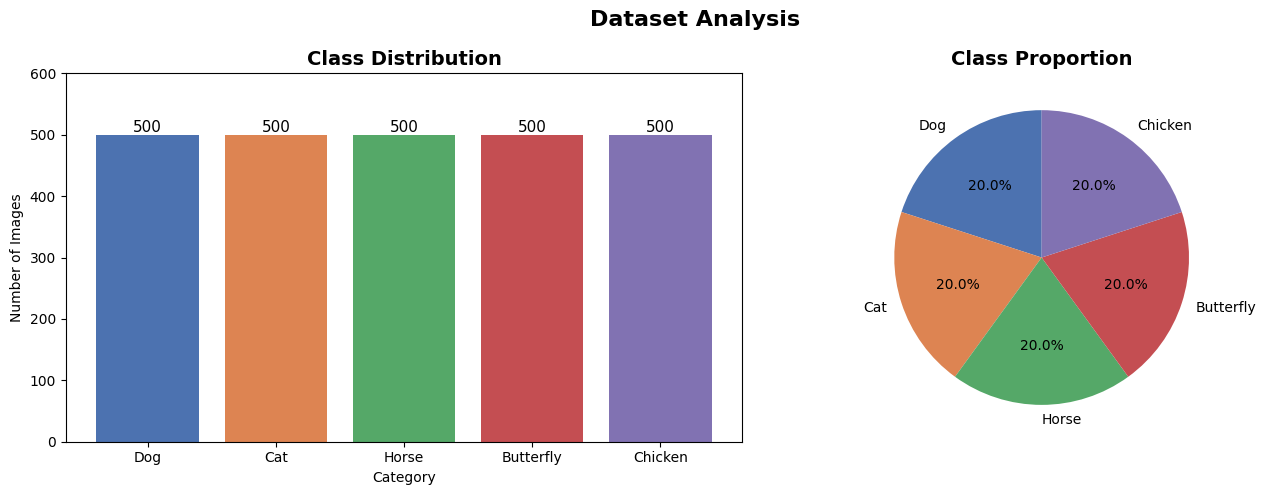

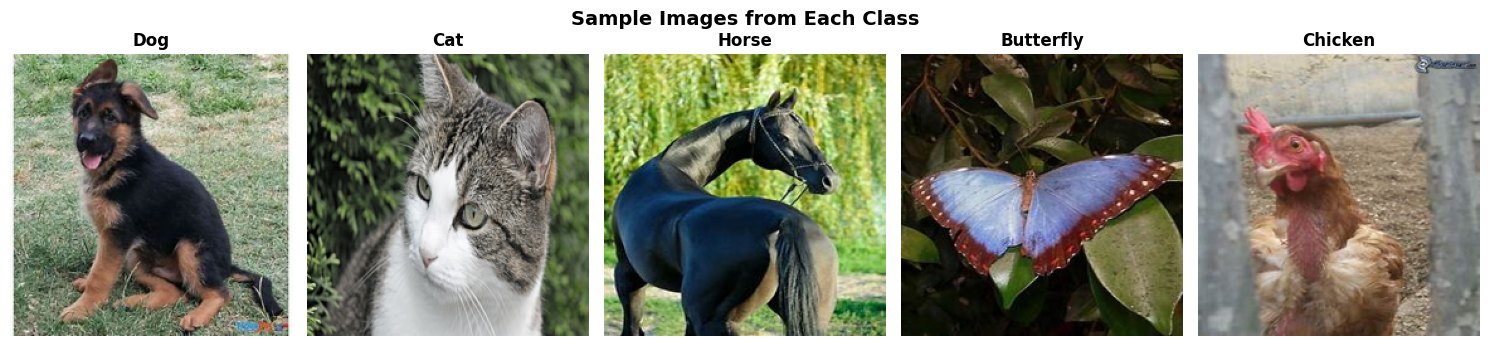

✅ 圖表已儲存：data_distribution.png、sample_images.png


In [6]:
# 類別分布直方圖 + 餅圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
bars = axes[0].bar(label_count.keys(), label_count.values(), color=colors)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category'); axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, MAX_PER_CLASS * 1.2)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha='center', fontsize=11)

axes[1].pie(label_count.values(), labels=label_count.keys(),
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Dataset Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 各類別範例影像（每類 1 張）
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3*NUM_CLASSES, 3.5))
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    sample_path = next(p for p, l in all_samples if l == cls_idx)
    img = Image.open(sample_path).convert('RGB').resize((224, 224))
    axes[cls_idx].imshow(img)
    axes[cls_idx].set_title(cls_name, fontsize=12, fontweight='bold')
    axes[cls_idx].axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 圖表已儲存：data_distribution.png、sample_images.png")

## Cell 6：資料前處理 與 DataLoader

In [7]:
# 訓練集：加入資料增強
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),            # 統一尺寸
    transforms.RandomHorizontalFlip(p=0.5),             # 隨機水平翻轉
    transforms.RandomCrop(IMG_SIZE, padding=20),        # 隨機裁剪
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(                               # ImageNet 標準化
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]),
])

# 驗證/測試集
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 切分訓練 / 驗證 / 測試集
total   = len(all_samples)
n_train = int(total * 0.70)
n_val   = int(total * 0.15)
n_test  = total - n_train - n_val

train_samples = all_samples[:n_train]
val_samples   = all_samples[n_train:n_train + n_val]
test_samples  = all_samples[n_train + n_val:]

print(f"訓練集：{len(train_samples)} 張 | 驗證集：{len(val_samples)} 張 | 測試集：{len(test_samples)} 張")

# 建立 Dataset 與 DataLoader
train_dataset = AnimalDataset(train_samples, transform=train_transform)
val_dataset   = AnimalDataset(val_samples,   transform=val_test_transform)
test_dataset  = AnimalDataset(test_samples,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"每批次：{BATCH_SIZE} 張 | 訓練批次數：{len(train_loader)}")

訓練集：1750 張 | 驗證集：375 張 | 測試集：375 張
每批次：32 張 | 訓練批次數：55


## Cell 7：任務 1 — 自定義 CNN 架構


In [8]:
class CustomCNN(nn.Module):
    """
    自定義卷積神經網路（From Scratch）
    架構：4 個 Conv Block → AdaptiveAvgPool → 全連接分類頭
    """
    def __init__(self, num_classes=5):
        super(CustomCNN, self).__init__()

        # Conv Block 1
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 卷積層
            nn.BatchNorm2d(32),                            # 批次正規化
            nn.ReLU(inplace=True),                         # 激活函數
            nn.MaxPool2d(kernel_size=2, stride=2),         # 最大池化，尺寸縮半
        )
        # Conv Block 2
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # Conv Block 3
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # Conv Block 4
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # 自適應平均池化：固定輸出 7
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))

        # 分類頭：Flatten → Linear → Dropout → Linear
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),                 # Dropout 0.4
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.3),                 # Dropout 0.3
            nn.Linear(128, num_classes),        # 最終輸出
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x


# ── 建立模型並驗證參數量
cnn_model     = CustomCNN(num_classes=NUM_CLASSES).to(device)
total_params  = sum(p.numel() for p in cnn_model.parameters())
train_params  = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

print(f"📐 總參數量     ：{total_params:,}  ({total_params/1e6:.2f}M)")
print(f"📐 可訓練參數量 ：{train_params:,}")
assert total_params <= 15_000_000, "❌ 超過 15M 參數上限！"
print("✅ 參數量符合規定（≤ 15M）")

📐 總參數量     ：6,878,725  (6.88M)
📐 可訓練參數量 ：6,878,725
✅ 參數量符合規定（≤ 15M）


## Cell 8：共用訓練 / 評估函式

In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    """訓練一個 Epoch，回傳平均 Loss 與 Accuracy"""
    model.train()   # 訓練模式：啟用 Dropout、BatchNorm
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # 1. 梯度清零
        outputs = model(images)        # 2. 前向傳播
        loss    = criterion(outputs, labels)  # 3. 計算損失
        loss.backward()                # 4. 反向傳播
        optimizer.step()               # 5. 更新參數

        running_loss += loss.item() * images.size(0)
        _, predicted  = torch.max(outputs, 1)
        correct      += (predicted == labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    """在驗證/測試集上評估，回傳平均 Loss 與 Accuracy"""
    model.eval()    # 評估模式：關閉 Dropout
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():   # 不計算梯度，省記憶體
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted  = torch.max(outputs, 1)
            correct      += (predicted == labels).sum().item()
            total        += labels.size(0)

    return running_loss / total, correct / total


def get_predictions(model, loader):
    """取得全部預測結果與真實標籤（用於混淆矩陣）"""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images   = images.to(device)
            outputs  = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


def plot_curves(train_losses, val_losses, train_accs, val_accs, title, fname, num_classes):
    """繪製 Loss 與 Accuracy 訓練曲線"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(train_losses) + 1)

    axes[0].plot(epochs, train_losses, 'b-o', markersize=3, label='Train Loss')
    axes[0].plot(epochs, val_losses,   'r-o', markersize=3, label='Val Loss')
    axes[0].set_title(f'{title}：Loss 曲線', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, train_accs, 'b-o', markersize=3, label='Train Acc')
    axes[1].plot(epochs, val_accs,   'r-o', markersize=3, label='Val Acc')
    axes[1].axhline(y=3/num_classes, color='gray', linestyle='--',
                    label=f'3× 隨機基準 ({3/num_classes:.2f})')
    axes[1].set_title(f'{title}：Accuracy 曲線', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(labels, preds, class_names, title, fname, cmap='Blues'):
    """繪製混淆矩陣 Heatmap"""
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='gray')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label（預測標籤）', fontsize=12)
    plt.ylabel('Actual Label（真實標籤）', fontsize=12)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    return cm


print("✅ 共用函式定義完成")

✅ 共用函式定義完成


## Cell 9：任務 1 — 開始訓練

In [10]:
T1_EPOCHS = 30
T1_LR     = 1e-3
T1_WD     = 1e-4

criterion_t1 = nn.CrossEntropyLoss()
optimizer_t1 = optim.Adam(cnn_model.parameters(), lr=T1_LR, weight_decay=T1_WD)
# 每 10 個 epoch 學習率乘以 0.5（避免後期震盪）
scheduler_t1 = optim.lr_scheduler.StepLR(optimizer_t1, step_size=10, gamma=0.5)

t1_train_losses, t1_val_losses = [], []
t1_train_accs,   t1_val_accs   = [], []
t1_best_val_acc  = 0.0
t1_best_weights  = None
t1_start_time    = time.time()

print("=" * 60)
print("🚀 任務 1：開始訓練自定義 CNN")
print("=" * 60)

for epoch in range(1, T1_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, criterion_t1, optimizer_t1)
    val_loss,   val_acc   = evaluate(cnn_model, val_loader, criterion_t1)
    scheduler_t1.step()

    t1_train_losses.append(train_loss); t1_val_losses.append(val_loss)
    t1_train_accs.append(train_acc);   t1_val_accs.append(val_acc)

    if val_acc > t1_best_val_acc:      # 儲存最佳驗證集權重
        t1_best_val_acc = val_acc
        t1_best_weights = copy.deepcopy(cnn_model.state_dict())

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{T1_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

t1_total_time = time.time() - t1_start_time
cnn_model.load_state_dict(t1_best_weights)   # 載回最佳權重
print(f"\n✅ 訓練完成！耗時 {t1_total_time:.1f} 秒")
print(f"📈 最佳驗證集準確率：{t1_best_val_acc:.4f}")

🚀 任務 1：開始訓練自定義 CNN
Epoch 01/30 | Train Loss: 1.7680 Acc: 0.2634 | Val Loss: 1.4663 Acc: 0.2960
Epoch 05/30 | Train Loss: 1.3080 Acc: 0.4457 | Val Loss: 1.2338 Acc: 0.4560
Epoch 10/30 | Train Loss: 1.1370 Acc: 0.5543 | Val Loss: 1.4525 Acc: 0.4613
Epoch 15/30 | Train Loss: 0.9520 Acc: 0.6354 | Val Loss: 0.9444 Acc: 0.5973
Epoch 20/30 | Train Loss: 0.9240 Acc: 0.6389 | Val Loss: 0.8885 Acc: 0.6427
Epoch 25/30 | Train Loss: 0.8179 Acc: 0.6869 | Val Loss: 0.7961 Acc: 0.6587
Epoch 30/30 | Train Loss: 0.7768 Acc: 0.7046 | Val Loss: 0.7535 Acc: 0.6880

✅ 訓練完成！耗時 506.5 秒
📈 最佳驗證集準確率：0.7120


## Cell 10：任務 1 — 評估、訓練曲線、混淆矩陣

📊 任務 1 測試集結果
  Accuracy  (準確率) : 0.6853
  Precision (精確率) : 0.6833
  Recall    (召回率) : 0.6819
  F1-Score  (巨觀)   : 0.6825
  3× 隨機猜測門檻   : 0.6000
✅ 達到 3 倍隨機猜測門檻！

               precision    recall  f1-score   support

         Dog       0.46      0.46      0.46        71
         Cat       0.55      0.55      0.55        76
       Horse       0.80      0.77      0.78        77
   Butterfly       0.85      0.85      0.85        79
     Chicken       0.77      0.78      0.77        72

    accuracy                           0.69       375
   macro avg       0.68      0.68      0.68       375
weighted avg       0.69      0.69      0.69       375



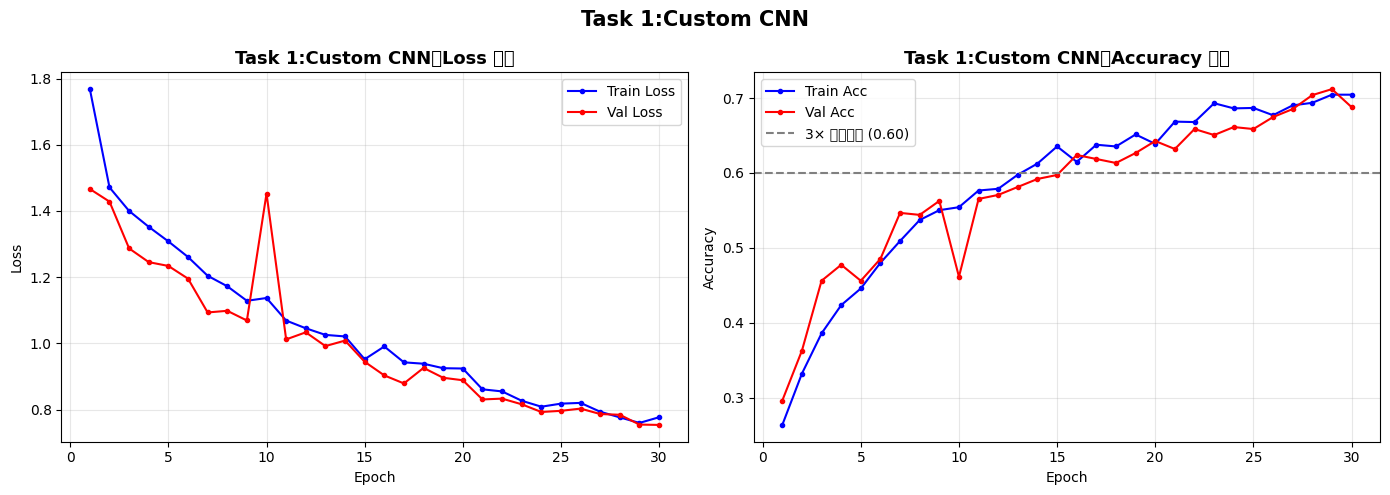

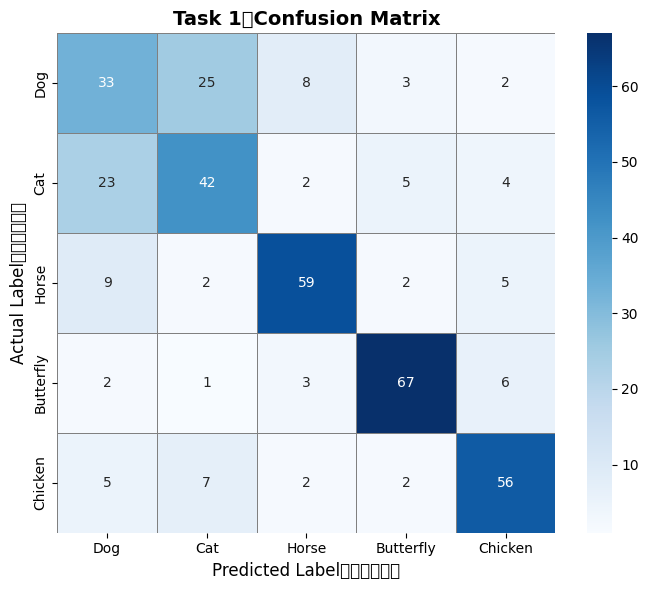

In [11]:
# 測試集評估
t1_labels, t1_preds = get_predictions(cnn_model, test_loader)

t1_accuracy  = accuracy_score(t1_labels, t1_preds)
t1_precision = precision_score(t1_labels, t1_preds, average='macro', zero_division=0)
t1_recall    = recall_score(t1_labels, t1_preds, average='macro', zero_division=0)
t1_f1        = f1_score(t1_labels, t1_preds, average='macro', zero_division=0)

print("=" * 50)
print("📊 任務 1 測試集結果")
print("=" * 50)
print(f"  Accuracy  (準確率) : {t1_accuracy:.4f}")
print(f"  Precision (精確率) : {t1_precision:.4f}")
print(f"  Recall    (召回率) : {t1_recall:.4f}")
print(f"  F1-Score  (巨觀)   : {t1_f1:.4f}")
print(f"  3× 隨機猜測門檻   : {3/NUM_CLASSES:.4f}")
assert t1_accuracy >= 3 / NUM_CLASSES, "❌ 未達到 3 倍隨機猜測門檻！"
print("✅ 達到 3 倍隨機猜測門檻！")
print("\n", classification_report(t1_labels, t1_preds, target_names=CLASS_NAMES))

# 訓練曲線
plot_curves(t1_train_losses, t1_val_losses, t1_train_accs, t1_val_accs,
            'Task 1:Custom CNN', 'task1_curves.png', NUM_CLASSES)

# 混淆矩陣
cm1 = plot_confusion_matrix(t1_labels, t1_preds, CLASS_NAMES,
                             'Task 1：Confusion Matrix',
                             'task1_confusion_matrix.png', cmap='Blues')

## Cell 11：任務 2 — 載入 ResNet-18 並修改分類頭


In [12]:
# 載入 ResNet-18 預訓練模型（ImageNet 權重）
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
print("✅ 載入 ResNet-18 預訓練權重")

# 凍結所有層的權重
for param in resnet18.parameters():
    param.requires_grad = False

# 替換最後一層全連接層
in_features = resnet18.fc.in_features   # 取得原始 FC 輸入維度
resnet18.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.3),
    nn.Linear(256, NUM_CLASSES),         # 輸出：5 類
)

resnet18 = resnet18.to(device)

total_t2    = sum(p.numel() for p in resnet18.parameters())
trainable_t2= sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f"📐 總參數量           ：{total_t2:,}")
print(f"📐 可訓練參數（分類頭）：{trainable_t2:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 128MB/s]


✅ 載入 ResNet-18 預訓練權重
📐 總參數量           ：11,309,125
📐 可訓練參數（分類頭）：132,613


## Cell 12：任務 2 — 開始訓練

In [13]:
T2_EPOCHS = 20
T2_LR     = 1e-3

criterion_t2 = nn.CrossEntropyLoss()
optimizer_t2 = optim.Adam(
    filter(lambda p: p.requires_grad, resnet18.parameters()),  # 只更新可訓練參數
    lr=T2_LR, weight_decay=1e-4
)

scheduler_t2 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_t2, T_max=T2_EPOCHS, eta_min=1e-5
)

t2_train_losses, t2_val_losses = [], []
t2_train_accs,   t2_val_accs   = [], []
t2_best_val_acc  = 0.0
t2_best_weights  = None
t2_start_time    = time.time()

print("=" * 60)
print("🚀 任務 2：開始訓練 ResNet-18（僅訓練分類頭）")
print("=" * 60)

for epoch in range(1, T2_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(resnet18, train_loader, criterion_t2, optimizer_t2)
    val_loss,   val_acc   = evaluate(resnet18, val_loader, criterion_t2)
    scheduler_t2.step()

    t2_train_losses.append(train_loss); t2_val_losses.append(val_loss)
    t2_train_accs.append(train_acc);   t2_val_accs.append(val_acc)

    if val_acc > t2_best_val_acc:
        t2_best_val_acc = val_acc
        t2_best_weights = copy.deepcopy(resnet18.state_dict())

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{T2_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

t2_total_time = time.time() - t2_start_time
resnet18.load_state_dict(t2_best_weights)
print(f"\n✅ 訓練完成！耗時 {t2_total_time:.1f} 秒")
print(f"📈 最佳驗證集準確率：{t2_best_val_acc:.4f}")

🚀 任務 2：開始訓練 ResNet-18（僅訓練分類頭）
Epoch 01/20 | Train Loss: 0.5015 Acc: 0.8491 | Val Loss: 0.1166 Acc: 0.9653
Epoch 05/20 | Train Loss: 0.1431 Acc: 0.9520 | Val Loss: 0.1349 Acc: 0.9467
Epoch 10/20 | Train Loss: 0.1142 Acc: 0.9606 | Val Loss: 0.0746 Acc: 0.9707
Epoch 15/20 | Train Loss: 0.0870 Acc: 0.9709 | Val Loss: 0.0540 Acc: 0.9813
Epoch 20/20 | Train Loss: 0.0710 Acc: 0.9754 | Val Loss: 0.0483 Acc: 0.9840

✅ 訓練完成！耗時 264.4 秒
📈 最佳驗證集準確率：0.9893


##  Cell 13：任務 2 — 評估、訓練曲線、混淆矩陣

📊 任務 2 測試集結果
  Accuracy  (準確率) : 0.9707
  Precision (精確率) : 0.9709
  Recall    (召回率) : 0.9695
  F1-Score  (巨觀)   : 0.9697
✅ F1-Score 優於任務 1！（0.9697 > 0.6825）

               precision    recall  f1-score   support

         Dog       0.97      0.89      0.93        71
         Cat       0.95      1.00      0.97        76
       Horse       0.95      0.97      0.96        77
   Butterfly       1.00      1.00      1.00        79
     Chicken       0.99      0.99      0.99        72

    accuracy                           0.97       375
   macro avg       0.97      0.97      0.97       375
weighted avg       0.97      0.97      0.97       375



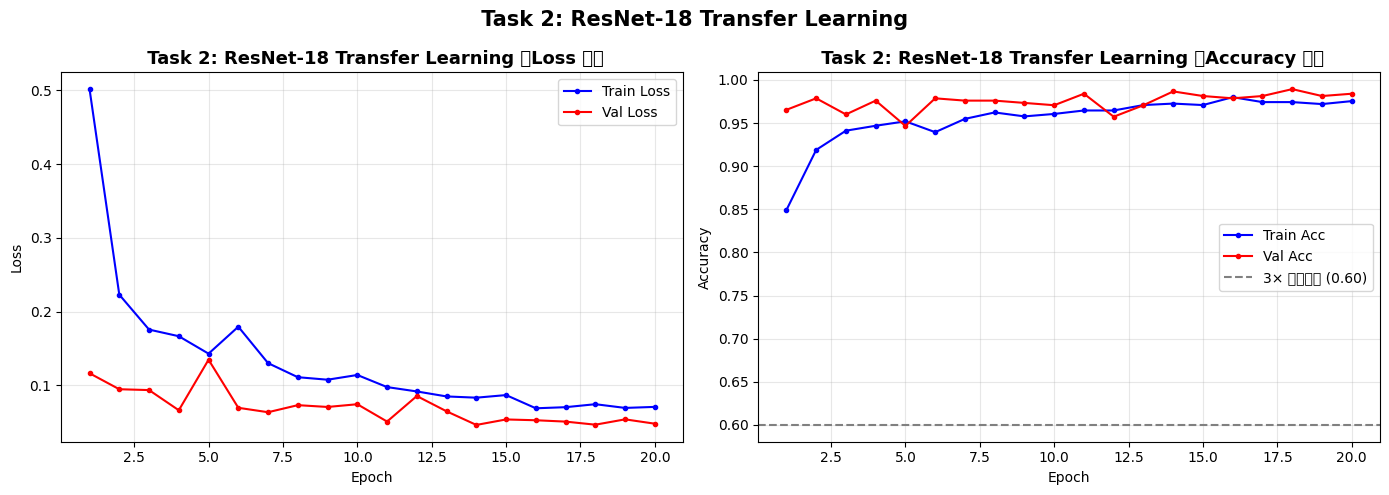

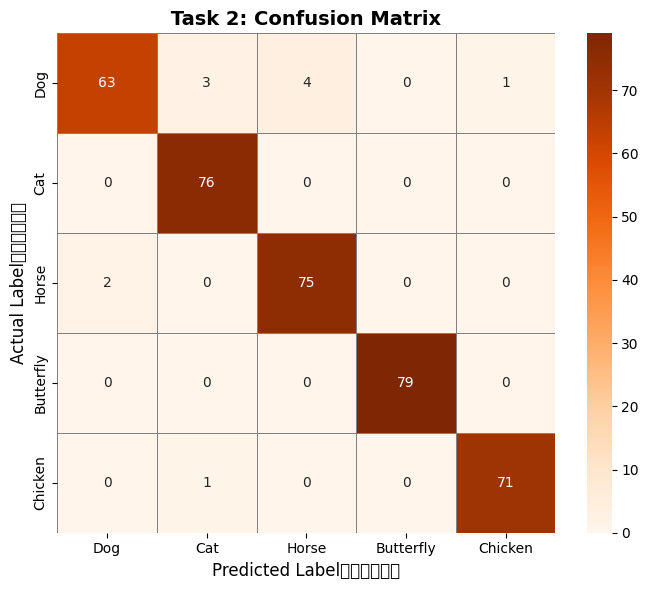

In [14]:
# 測試集評估
t2_labels, t2_preds = get_predictions(resnet18, test_loader)

t2_accuracy  = accuracy_score(t2_labels, t2_preds)
t2_precision = precision_score(t2_labels, t2_preds, average='macro', zero_division=0)
t2_recall    = recall_score(t2_labels, t2_preds, average='macro', zero_division=0)
t2_f1        = f1_score(t2_labels, t2_preds, average='macro', zero_division=0)

print("=" * 50)
print("📊 任務 2 測試集結果")
print("=" * 50)
print(f"  Accuracy  (準確率) : {t2_accuracy:.4f}")
print(f"  Precision (精確率) : {t2_precision:.4f}")
print(f"  Recall    (召回率) : {t2_recall:.4f}")
print(f"  F1-Score  (巨觀)   : {t2_f1:.4f}")
assert t2_f1 >= t1_f1, f"⚠️  F1-Score 未優於任務 1！（{t2_f1:.4f} vs {t1_f1:.4f}）"
print(f"✅ F1-Score 優於任務 1！（{t2_f1:.4f} > {t1_f1:.4f}）")
print("\n", classification_report(t2_labels, t2_preds, target_names=CLASS_NAMES))

# 訓練曲線
plot_curves(t2_train_losses, t2_val_losses, t2_train_accs, t2_val_accs,
            ' Task 2: ResNet-18 Transfer Learning ', 'task2_curves.png', NUM_CLASSES)

# 混淆矩陣
cm2 = plot_confusion_matrix(t2_labels, t2_preds, CLASS_NAMES,
                             ' Task 2: Confusion Matrix ',
                             'task2_confusion_matrix.png', cmap='Oranges')

## Cell 14：對比分析表格

In [15]:
total_params_t1 = sum(p.numel() for p in cnn_model.parameters())

print("\n" + "=" * 68)
print(f"{'評估指標':<22}{'任務1 (Custom CNN)':>20}{'任務2 (ResNet-18)':>24}")
print("=" * 68)
rows = [
    ("模型參數量 (Params)",   f"{total_params_t1:,}",       f"{total_t2:,}"),
    ("訓練總耗時 (Time)",     f"{t1_total_time:.1f} s",     f"{t2_total_time:.1f} s"),
    ("準確率 (Accuracy)",     f"{t1_accuracy:.4f}",         f"{t2_accuracy:.4f}"),
    ("精確率 (Precision)",    f"{t1_precision:.4f}",        f"{t2_precision:.4f}"),
    ("召回率 (Recall)",       f"{t1_recall:.4f}",           f"{t2_recall:.4f}"),
    ("F1-Score (Macro)",      f"{t1_f1:.4f}",               f"{t2_f1:.4f}"),
]
for metric, v1, v2 in rows:
    print(f"{metric:<22}{v1:>20}{v2:>24}")
print("=" * 68)


評估指標                      任務1 (Custom CNN)         任務2 (ResNet-18)
模型參數量 (Params)                   6,878,725              11,309,125
訓練總耗時 (Time)                       506.5 s                 264.4 s
準確率 (Accuracy)                      0.6853                  0.9707
精確率 (Precision)                     0.6833                  0.9709
召回率 (Recall)                        0.6819                  0.9695
F1-Score (Macro)                    0.6825                  0.9697


## Cell 15：錯誤分析（最易混淆的兩類 + 4 張誤判圖片）

🔍 任務 1 最易混淆：Dog → 誤判為 Cat（25 次）
   找到 25 張誤判圖片，展示前 4 張


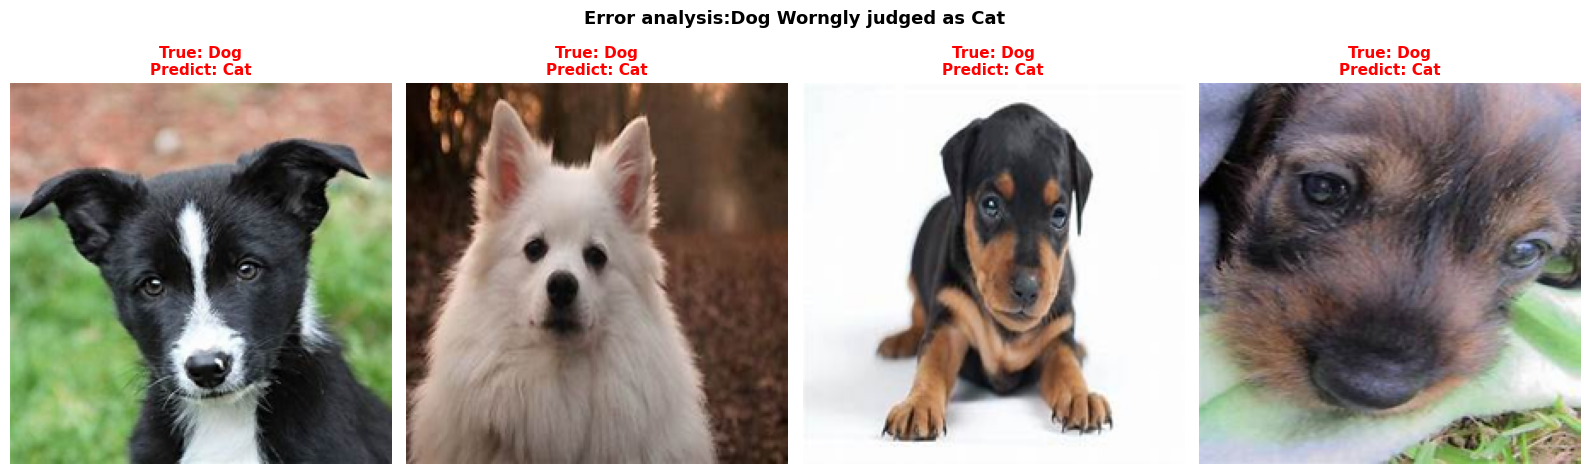

✅ 錯誤分析圖已儲存為 error_analysis.png


In [16]:
def find_most_confused_pair(cm, class_names):
    """從混淆矩陣找出誤判次數最多的兩個類別"""
    cm_copy = cm.copy().astype(float)
    np.fill_diagonal(cm_copy, 0)   # 忽略對角線
    i, j = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)
    return i, j, int(cm_copy[i, j])

pair_i, pair_j, count = find_most_confused_pair(cm1, CLASS_NAMES)
print(f"🔍 任務 1 最易混淆：{CLASS_NAMES[pair_i]} → 誤判為 {CLASS_NAMES[pair_j]}（{count} 次）")

# 找出被誤判的圖片路徑
misclassified = [
    (test_samples[k][0], t1_labels[k], t1_preds[k])
    for k in range(len(t1_labels))
    if t1_labels[k] == pair_i and t1_preds[k] == pair_j
]
print(f"   找到 {len(misclassified)} 張誤判圖片，展示前 4 張")

# 展示前 4 張
show_n = min(4, len(misclassified))
if show_n > 0:
    fig, axes = plt.subplots(1, show_n, figsize=(4 * show_n, 4.5))
    if show_n == 1: axes = [axes]
    for idx in range(show_n):
        path, true_lbl, pred_lbl = misclassified[idx]
        img = Image.open(path).convert('RGB').resize((224, 224))
        axes[idx].imshow(img)
        axes[idx].set_title(
            f"True: {CLASS_NAMES[true_lbl]}\nPredict: {CLASS_NAMES[pred_lbl]}",
            fontsize=11, color='red', fontweight='bold')
        axes[idx].axis('off')
    plt.suptitle(f'Error analysis:{CLASS_NAMES[pair_i]} Worngly judged as {CLASS_NAMES[pair_j]}',
                 fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ 錯誤分析圖已儲存為 error_analysis.png")
else:
    print("⚠️  沒有找到誤判圖片（模型表現很好！）")